# Importações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Lendo o dataset e tirando as primeiras informações

*"Dataset extraído do Kaggle: [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)"*.

In [2]:
df = pd.read_csv("data/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# EDA (Análise Exploratória de Dados)

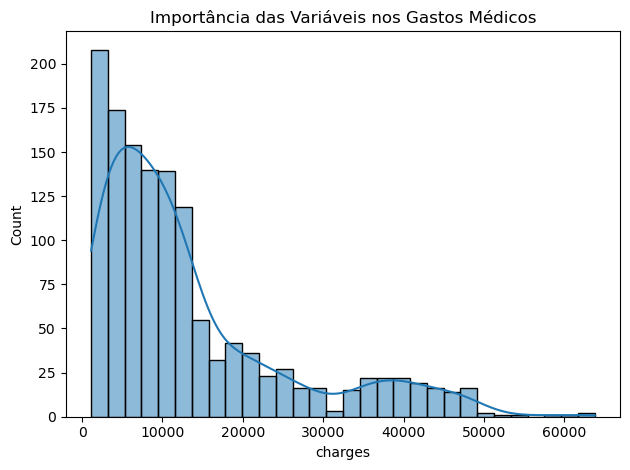

In [24]:
# Gráfico de histograma
sns.histplot(df["charges"], kde=True)
plt.title('Importância das Variáveis nos Gastos Médicos')
plt.tight_layout()

# Salvando
plt.savefig('img/feature_importance.png', dpi=300, facecolor='white')
plt.show()

### Análise da Variável Alvo (Charges)
O histograma revela que a distribuição dos custos de seguro é **assimétrica à direita**. 
* A maior concentração de dados está na faixa abaixo de 15.000.
* Existe uma lacuna e depois alguns picos em valores mais altos, sugerindo que grupos específicos (como fumantes) podem estar distorcendo a média para cima.

<Axes: >

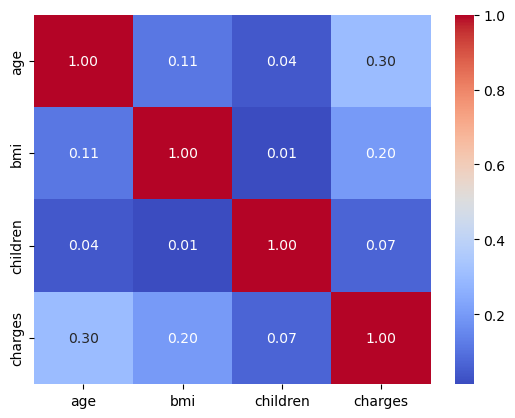

In [8]:
# Criando um mapa de calor para identificar relações fortes
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

### Análise da correlação entre as colunas númericas.
O mapa de calor revela que a correlação entre as variaveis age, bmi, children e charges são muito baixas entre elas.

<Axes: xlabel='smoker', ylabel='charges'>

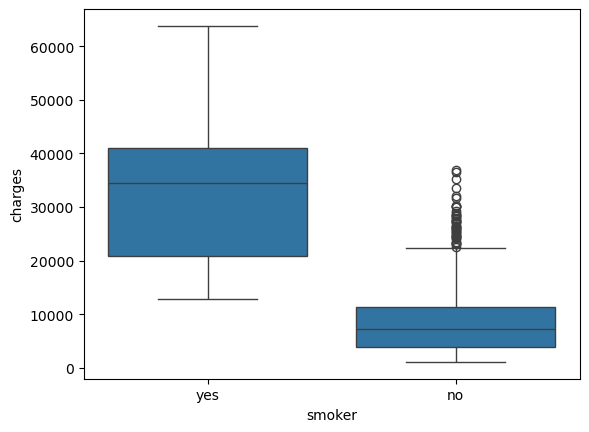

In [9]:
# Gráfico de boxplot
sns.boxplot(x="smoker", y="charges", data=df)

### Análise de Impacto: Tabagismo
A variável smoker apresenta a maior influência visual nos custos de seguro até o momento.
* Fumantes: Concentração de custos elevada (20k - 40k).
* Não-Fumantes: Custos significativamente menores, porém com presença de outliers que ultrapassam os 20k, sugerindo a influência de outras variáveis (provavelmente bmi ou age).


<Axes: xlabel='bmi', ylabel='charges'>

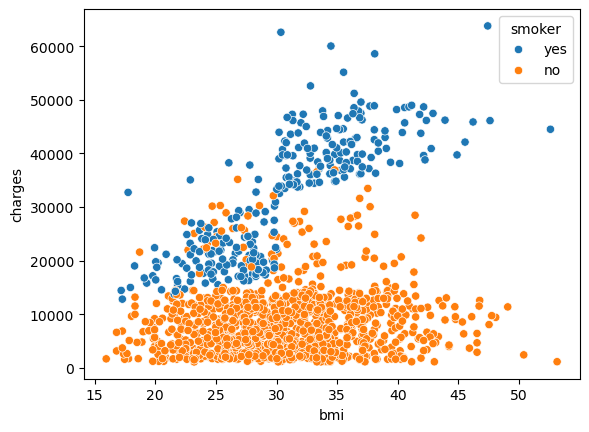

In [10]:
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df)

<Axes: xlabel='age', ylabel='charges'>

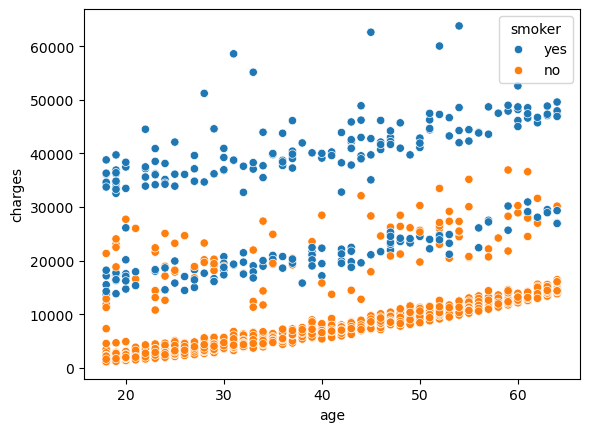

In [11]:
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)

### Análise de Gastos: Tabagismo x BMI e Idade
O fumo é o "gatilho", mas o BMI é o que decide se o custo do fumante será "alto" ou "altíssimo".
* Fumantes com BMI abaixo de 30 pagam por volta de 20.000.
* Fumantes com BMI acima de 30 (limite da obesidade) dão um salto enorme para a faixa dos 40.000+.
* conforme a idade sobe, o custo base de todo mundo sobe um pouco.

# Pré-processamento de Dados

### Encoding

In [12]:
df_model = df.copy()

# Convertendo as variaveis smoker e sex para binarios.
df_model["smoker"] = df_model["smoker"].map({"yes": 1, "no": 0})
df_model["sex"] = df_model["sex"].map({"female": 1, "male": 0})

# Convertendo a variável regional usando One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=["region"], drop_first=True)

In [13]:
df_model

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


### Feature Selection

In [14]:
# Separando as variaveis X e y
X = df_model.drop("charges", axis=1)
y = df_model["charges"]

### Divisão e Treinamento

In [15]:
# Dividindo os dados em conjuntos de treino e teste
# random_state=42 garante que a divisão seja sempre a mesma ao rodar o código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo 1- Regressão Linear

In [16]:
# Criando o objeto do modelo
model_rl = LinearRegression()

# Treinando o modelo com os dados de treino
model_rl.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# O modelo usa os pesos que aprendeu para estimar os valores de teste
y_pred_rl = model_rl.predict(X_test)

# Modelo 2- Random Forest

In [18]:
# Criando o objeto do modelo
rf_model = RandomForestRegressor()

# Treinando o modelo
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred_rf = rf_model.predict(X_test)

In [20]:
# Importancia das variaveis
importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp

smoker              0.606494
bmi                 0.216721
age                 0.134775
children            0.019945
sex                 0.006628
region_northwest    0.006136
region_southeast    0.005279
region_southwest    0.004023
dtype: float64

### Análise de Importância das Variáveis (Feature Importance)

Após o treinamento do modelo de **Random Forest**, analisamos quais características foram mais relevantes para o cálculo das predições:

* **Variável Crítica:** O status de **fumante (smoker)** é, de longe, o fator mais impactante, sendo responsável pela maior parte da variação nos preços.
* **Fatores Biométricos:** O **IMC (bmi)** e a **idade (age)** aparecem como o segundo e terceiro fatores mais importantes, respectivamente. O modelo identifica que o risco aumenta progressivamente com esses dois indicadores.
* **Fatores Irrelevantes:** Variáveis como sexo, número de filhos e região geográfica apresentam importância mínima, indicando que o gasto é definido primordialmente por hábitos de saúde e indicadores físicos.

# Avaliação

In [21]:
def avaliar(y_test, y_pred, nome):
    print(f"--- {nome} ---")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

avaliar(y_test, y_pred_rl, "Linear Regression")
print('')
avaliar(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MSE: 33596915.85136145
R2: 0.7835929767120724

--- Random Forest ---
MSE: 21327106.01437432
R2: 0.8626262140151243


### Análise do Modelo: Regressão Linear
A **Regressão Linear** serviu como nossa base (baseline). Ela tenta encontrar uma linha média que minimize a distância entre os gastos reais e as previsões.

* **Desempenho (R²):** 0.78
* **Interpretação:** O modelo explica **78%** da variabilidade dos gastos médicos.
* **Observação Clínica:** O modelo é muito bom para prever gastos de rotina (consultas e procedimentos simples), mas "sofre" para prever gastos de alta complexidade. Isso ocorre porque a relação entre fumo/BMI e gastos médicos não é uma linha reta suave, mas sim composta por saltos bruscos de custo.

### Análise do Modelo: Random Forest (Floresta Aleatória)
O **Random Forest** utiliza um conjunto de árvores de decisão para capturar padrões não-lineares, o que se mostrou ideal para prever gastos hospitalares e clínicos.

* **Desempenho (R²):** 0.86
* **Importância das Variáveis (Feature Importance):**
    1. **smoker:** Principal indicador de gastos elevados.
    2. **bmi:** Segundo maior impacto, indicando que condições metabólicas elevam o custo médico.
    3. **age:** Terceiro fator, representando o desgaste natural e maior recorrência clínica.
* **Vantagem Técnica:** Este modelo superou a Regressão Linear porque conseguiu mapear que pacientes com "BMI alto + Fumantes" geram gastos médicos desproporcionalmente maiores, algo que uma linha reta simples não consegue descrever.

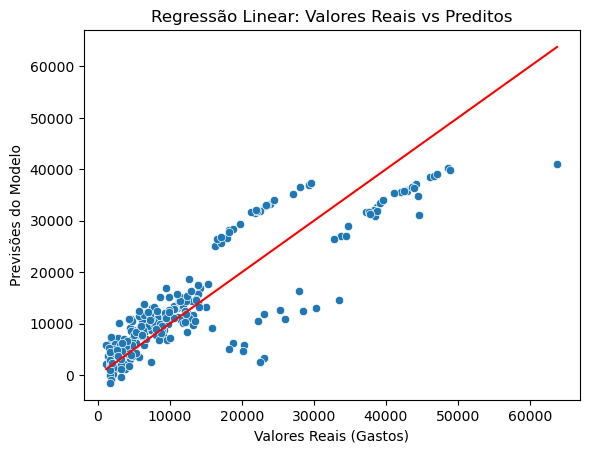

In [27]:
sns.scatterplot(x=y_test, y=y_pred_rl)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title('Regressão Linear: Valores Reais vs Preditos')
plt.xlabel('Valores Reais (Gastos)')
plt.ylabel('Previsões do Modelo')

# SALVAR NESTE LOCAL:
plt.savefig('img/rl_real_vs_predito.png', dpi=300, facecolor='white')
plt.show()

### Análise Visual: Valores Reais vs. Preditos (Linear Regression)

O gráfico de dispersão acima permite avaliar visualmente a precisão do modelo de Regressão Linear:

* **Alinhamento:** Existe uma forte tendência linear, confirmada pelo $R^2$ de 0.78. Os pontos seguem a direção da linha vermelha ideal.
* **Precisão por Faixa de Custo:**
    * **Custos Baixos (< 15k):** O modelo apresenta alta precisão, com os pontos muito próximos à linha de referência.
    * **Custos Altos (> 30k):** Há uma dispersão maior. O modelo tende a subestimar ou superestimar valores extremos, o que é comum na Regressão Linear quando os dados possuem comportamentos categóricos fortes (como o salto de preço para fumantes).
* **Conclusão:** O gráfico mostra que o modelo capturou o padrão geral dos dados, mas a organização dos pontos em "camadas" sugere que um modelo não-linear (como o Random Forest) pode se ajustar melhor a esses saltos de valor.


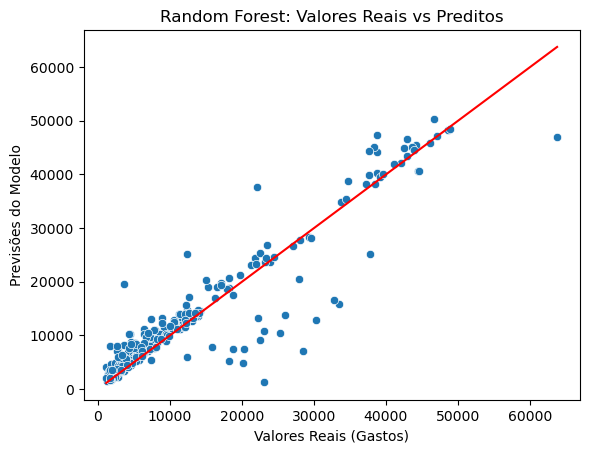

In [26]:
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title('Random Forest: Valores Reais vs Preditos')
plt.xlabel('Valores Reais (Gastos)')
plt.ylabel('Previsões do Modelo')

# Salvando
plt.savefig('img/rf_real_vs_predito.png', dpi=300, facecolor='white')
plt.show()

### Análise Visual: Valores Reais vs. Preditos (Random Forest)

Este gráfico demonstra a superioridade do modelo de **Random Forest** em relação ao modelo linear anterior:

* **Ajuste Superior:** A maior concentração de pontos sobre a linha vermelha tracejada reflete o aumento do **R² para 0.86**. 
* **Captura de Não-Linearidade:** Diferente da Regressão Linear, o Random Forest conseguiu captar os "saltos" de custo causados pela interação entre fumo e BMI, eliminando grande parte do erro sistemático que víamos anteriormente.
* **Consistência:** O modelo mantém uma boa performance tanto em custos baixos quanto em custos moderadamente altos (até 45.000).
* **Conclusão Visual:** O alinhamento dos pontos confirma que a escolha por um modelo baseado em árvores de decisão foi correta para este conjunto de dados, pois ele lida melhor com a complexidade e as categorias do dataset.

# Conclusão

### Principais Insights
* **Perfil de Alto Gasto:** O maior impacto nos gastos médicos vem do tabagismo combinado com o IMC elevado. Para uma gestão de clínica, esses são os pacientes que exigem maior provisão de recursos.
* **Estabilidade Base:** A idade causa um aumento previsível e gradual nos gastos, enquanto o hábito de fumar causa picos súbitos de custo.
* **Dados Demográficos:** Sexo e região não apresentaram relevância significativa na composição dos gastos médicos neste conjunto de dados.

### Melhor Modelo
O **Random Forest Regressor** é o modelo recomendado para produção. Com um **R² de 0.86**, ele oferece uma margem de segurança muito maior para prever orçamentos médicos e faturamentos clínicos do que a regressão simples.

### Limitações
* **Variáveis Externas:** O modelo explica 86% dos gastos. Os 14% restantes provavelmente se devem a fatores não mapeados, como tipos de procedimentos específicos, internações de emergência ou doenças crônicas não listadas.
* **Uso Prático:** Este modelo é uma ferramenta de auxílio à decisão e deve ser atualizado conforme os custos médicos e tabelas de preços da clínica sofram reajustes anuais.